In [3]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

MG_imports = {
    'ESN': {
        'net_wide': {
            'dd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-29_BL_dist_decay_net_wide.p"},
            'fd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_BL_fixed_decay_net_wide.p"}
        },
        'per_cluster': {
            'dd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_BL_dist_decay_per_cluster.p"},
            'fd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_BL_fixed_decay_per_cluster.p"}
        }
    },
    'DDN':{
        'net_wide': {
            'dd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_DDN_dist_decay_net_wide.p"},
            'fd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_DDN_fixed_decay_net_wide.p"}
        },
        'per_cluster': {
            'dd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_DDN_dist_decay_per_cluster.p"},
            'fd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_DDN_fixed_decay_per_cluster.p"}
        }
    }
}

max_gen = 150


c:\Users\Nishant Joshi\anaconda3\envs\brian2\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
data = pkl.load(open(MG_imports['ESN']['net_wide']['dd']['path'], 'rb'))

In [40]:
data['tau range']

[12, 22]

# Validation Scores
Import and plot validation performances and hyperparameters

In [2]:
for net_type in MG_imports:
    for task_type in MG_imports[net_type]:
        for het_type in MG_imports[net_type][task_type]:
            with open(MG_imports[net_type][task_type][het_type]['path'], 'rb') as f:
                MG_imports[net_type][task_type][het_type]['results_dict'] = pkl.load(f)
                print(MG_imports[net_type][task_type][het_type]['results_dict'].keys())
                print(MG_imports[net_type][task_type][het_type]['results_dict']['alpha grid'])

dict_keys(['validation performance', 'parameters', 'evolutionary strategy', 'cma stds', 'error margin', 'number of sequences', 'number of samples', 'alpha grid', 'tau range', 'start value range', 'example net'])
[1e-08, 1e-06, 0.0001, 0.01, 1]
dict_keys(['validation performance', 'parameters', 'evolutionary strategy', 'cma stds', 'error margin', 'number of sequences', 'number of samples', 'alpha grid', 'tau range', 'start value range', 'example net'])
[1e-08, 1e-06, 0.0001, 0.01, 1]
dict_keys(['validation performance', 'parameters', 'evolutionary strategy', 'cma stds', 'error margin', 'number of sequences', 'number of samples', 'alpha grid', 'tau range', 'start value range', 'example net'])
[1e-08, 1e-06, 0.0001, 0.01, 1]
dict_keys(['validation performance', 'parameters', 'evolutionary strategy', 'cma stds', 'error margin', 'number of sequences', 'number of samples', 'alpha grid', 'tau range', 'start value range', 'example net'])
[1e-08, 1e-06, 0.0001, 0.01, 1]
dict_keys(['validation p

In [3]:
np.shape(MG_imports["DDN"]['net_wide']['dd']['results_dict']['validation performance'])

(200, 20, 5)

In [4]:
def MG_plot_df_from_evo_dict(dict, max_gen):
    df_dict = {
        'Generation' : [],
        'Prediction Horizon' : []
    }
    best_i = np.argmax(np.mean(dict['validation performance'][:max_gen, :, :], axis=-1),axis=-1)
    plot = []
    for ind, i in enumerate(best_i):
        plot.append(dict['validation performance'][ind, i, :])
    plot = np.array(plot)
    print(f"Shape of plot: {plot.shape}")
    for gen, pop in enumerate(plot):
        print(pop.shape)
        df_dict['Generation'] += list(np.repeat(gen, pop.shape))
        df_dict['Prediction Horizon'] += list(pop)
    df_plot = pd.DataFrame.from_dict(df_dict)
    return df_plot

In [5]:
for net_type in MG_imports:
    for task_type in MG_imports[net_type]:
        for het_type in MG_imports[net_type][task_type]:
            dict = MG_imports[net_type][task_type][het_type]['results_dict']
            plot_df = MG_plot_df_from_evo_dict(dict, max_gen)
            MG_imports[net_type][task_type][het_type]['evo_df'] = plot_df

Shape of plot: (150, 5)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
Shape of plot: (150, 5)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5

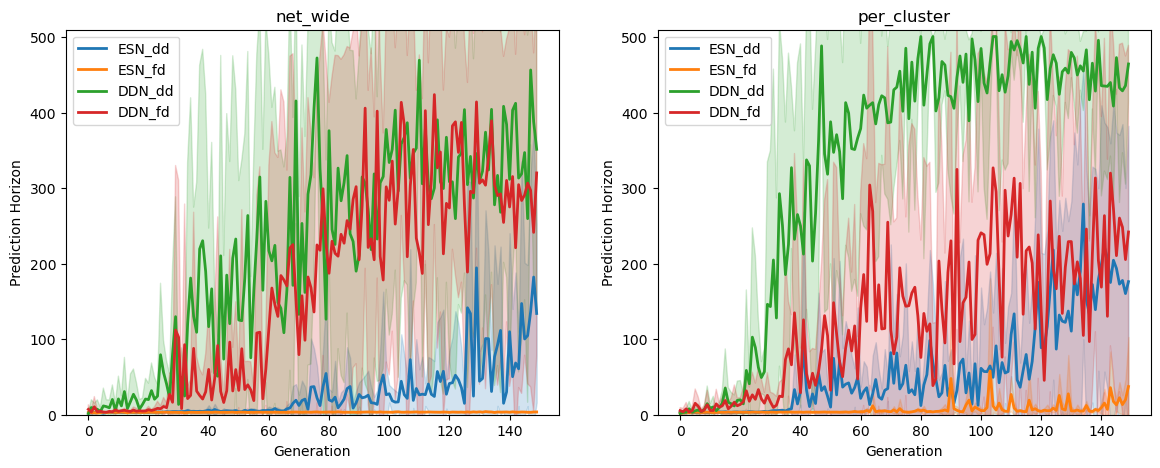

In [6]:
fig, ax= plt.subplots(1, 2, figsize=(14,5))
for net_type in MG_imports:
    for sp, task_type in enumerate(MG_imports[net_type]):
        ax[sp].set_title(task_type)
        ax[sp].set_ylim(0, 510)

        for het_type in MG_imports[net_type][task_type]:
            df_to_plot = MG_imports[net_type][task_type][het_type]['evo_df']
            plot_name = net_type + "_" + het_type
            sns.lineplot(df_to_plot, x='Generation', y='Prediction Horizon', ax=ax[sp], linewidth=2, linestyle="-",label=plot_name, errorbar='sd')

ax[0].legend(fontsize=10)
ax[1].legend(fontsize=10)


## Basic runs
Just standard ESN and DDN in fixed tau condition, as in chapter 3

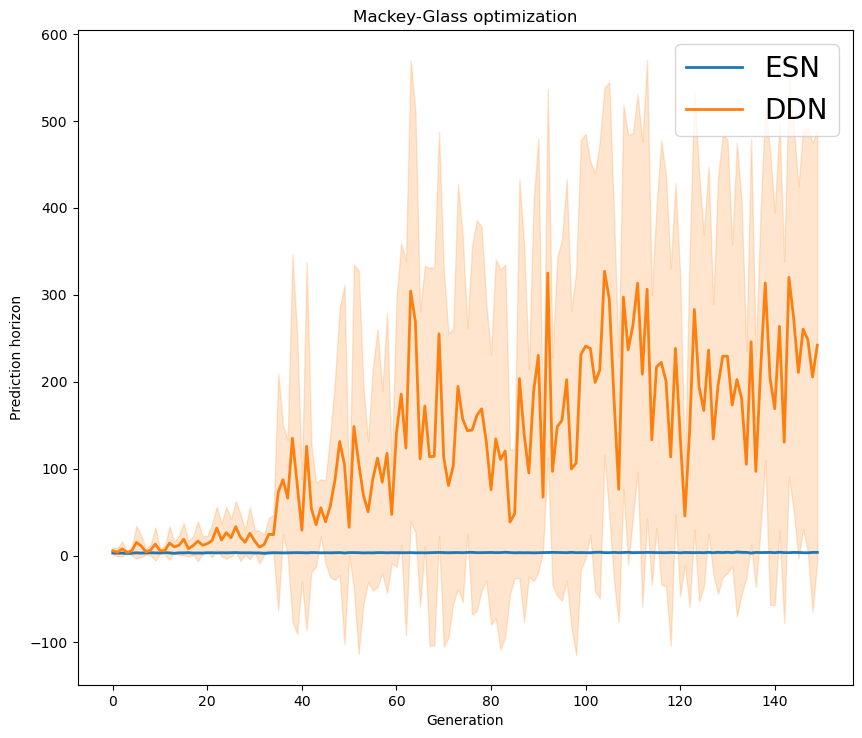

In [7]:
esn_df = MG_imports['ESN']['net_wide']['fd']['evo_df']
ddn_df = MG_imports['DDN']['per_cluster']['fd']['evo_df']
fig, ax= plt.subplots(figsize=(10,8.5))
sns.lineplot(esn_df, x='Generation', y='Prediction Horizon', ax=ax, linewidth=2, linestyle="-",label="ESN", errorbar='sd')
sns.lineplot(ddn_df, x='Generation', y='Prediction Horizon', ax=ax, linewidth=2, linestyle="-",label="DDN", errorbar='sd')
# sns.lineplot(DDN_plot, ax=ax, linewidth=2, linestyle="-", label="DDN")
# sns.lineplot(ADDN_plot, ax=ax, linewidth=2, linestyle="-", label="ADDN")
# plt.xlim(0,200)
plt.xlabel('Generation')
plt.ylabel('Prediction horizon')
plt.title('Mackey-Glass optimization')
ax.legend(fontsize=20)

# Test
Import and plot test performances

In [12]:
test_files_path = "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/"

In [13]:
for net_type in MG_imports:
    for task_type in MG_imports[net_type]:
        for het_type in MG_imports[net_type][task_type]:
            val_path = MG_imports[net_type][task_type][het_type]['path'].split('/')[-1].split('.')[0]
            test_path = test_files_path+ val_path + "_gen150_test_optimized.p"
            with open(test_path, 'rb') as f:
                MG_imports[net_type][task_type][het_type]['test_dict'] = pkl.load(f)
                print(MG_imports[net_type][task_type][het_type]['test_dict'])


{12: [[501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [47, 38, 47, 101, 501], [501, 239, 315, 219, 501], [501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [265, 266, 341, 184, 501], [501, 501, 501, 247, 501], [38, 38, 39, 57, 186], [501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [116, 117, 190, 140, 486], [501, 465, 501, 501, 501], [40, 39, 40, 94, 199], [501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [115, 76, 113, 56, 501], [265, 265, 340, 319, 501], [152, 120, 501, 131, 501], [501, 501, 501, 501, 501], [225, 149, 152, 132, 273], [501, 52, 76, 94, 501], [501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [377, 150, 151, 130, 501], [501, 501, 501, 501, 501], [203, 501, 501, 295, 501], [501, 315, 501, 144, 501], [501, 501, 501, 501, 501], [150, 225, 501, 206, 501], [90, 78, 126, 69, 501], [113, 103, 112, 93, 501], [491, 341, 501, 295, 501], [501, 501, 501, 501, 501], [416, 266, 341, 321, 501], [501, 501, 501, 501, 501], [501, 501, 501,

## Single Tau task

ESN dd
[[501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [47, 38, 47, 101, 501], [501, 239, 315, 219, 501], [501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [265, 266, 341, 184, 501], [501, 501, 501, 247, 501], [38, 38, 39, 57, 186], [501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [116, 117, 190, 140, 486], [501, 465, 501, 501, 501], [40, 39, 40, 94, 199], [501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [115, 76, 113, 56, 501], [265, 265, 340, 319, 501], [152, 120, 501, 131, 501], [501, 501, 501, 501, 501], [225, 149, 152, 132, 273], [501, 52, 76, 94, 501], [501, 501, 501, 501, 501], [501, 501, 501, 501, 501], [377, 150, 151, 130, 501], [501, 501, 501, 501, 501], [203, 501, 501, 295, 501], [501, 315, 501, 144, 501], [501, 501, 501, 501, 501], [150, 225, 501, 206, 501], [90, 78, 126, 69, 501], [113, 103, 112, 93, 501], [491, 341, 501, 295, 501], [501, 501, 501, 501, 501], [416, 266, 341, 321, 501], [501, 501, 501, 501, 501], [501, 501, 50

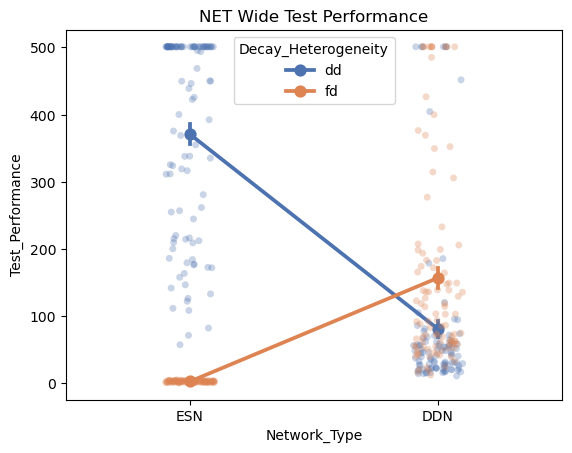

In [32]:
test_dict_pd = {
    'Network_Type': [],
    'Decay_Heterogeneity': [],
    'Test_Performance': []
}
for net_type in MG_imports:
    for het_type in MG_imports[net_type]['net_wide']:
        test_dict = MG_imports[net_type]['net_wide'][het_type]['test_dict']
        test_data = test_dict[12]
        print(net_type, het_type)
        print(test_data)
        test_data = list(np.average(test_data, axis=-1))       
         
        n_samples = len(test_data)
        test_dict_pd['Test_Performance'] += test_data
        test_dict_pd['Network_Type'] += [net_type] * n_samples
        test_dict_pd['Decay_Heterogeneity'] += [het_type] * n_samples

test_pd_network = pd.DataFrame.from_dict(test_dict_pd)
# sns.pointplot(test_df, x=x_label, y=y_label, hue=hue_label, errorbar='se', palette='deep', markers='o', markersize=5)

sns.pointplot(data=test_pd_network, x='Network_Type', hue='Decay_Heterogeneity', errorbar='se', y='Test_Performance', palette='deep', markers='o')

sns.stripplot(data=test_pd_network, x='Network_Type', hue='Decay_Heterogeneity', y='Test_Performance', legend=False, alpha=0.3, palette='deep')
plt.title('NET Wide Test Performance')
plt.savefig('G:/My Drive/Data For Publication/paper3/figs_MG/MG_net_wide_test_performance.pdf', dpi=300, bbox_inches='tight')

ESN dd
[[5, 12, 17, 7, 6], [22, 5, 3, 7, 3], [16, 15, 6, 7, 10], [24, 32, 6, 7, 16], [7, 21, 11, 7, 11], [13, 3, 6, 7, 11], [4, 67, 6, 4, 16], [7, 15, 3, 7, 8], [7, 10, 11, 3, 3], [5, 12, 3, 3, 6], [13, 12, 17, 7, 11], [18, 3, 6, 7, 11], [7, 12, 7, 7, 3], [11, 36, 11, 7, 11], [7, 17, 14, 7, 8], [18, 22, 11, 7, 11], [22, 21, 21, 3, 16], [4, 16, 6, 7, 11], [22, 11, 3, 6, 16], [22, 22, 6, 7, 11], [24, 37, 10, 7, 15], [4, 12, 6, 7, 15], [16, 12, 6, 7, 14], [16, 12, 6, 7, 11], [4, 16, 18, 7, 11], [7, 12, 6, 7, 6], [4, 16, 6, 7, 11], [23, 11, 3, 7, 1], [9, 17, 28, 7, 16], [24, 20, 18, 7, 11], [23, 16, 6, 7, 11], [18, 17, 17, 7, 16], [22, 12, 1, 7, 8], [4, 12, 3, 6, 11], [11, 16, 6, 7, 11], [16, 16, 5, 7, 11], [23, 37, 6, 7, 31], [18, 21, 14, 7, 16], [3, 36, 28, 3, 15], [7, 16, 6, 7, 11], [18, 36, 10, 7, 16], [23, 11, 3, 7, 11], [13, 37, 6, 7, 11], [22, 16, 6, 6, 15], [23, 32, 5, 7, 11], [7, 10, 6, 6, 6], [22, 11, 18, 7, 6], [13, 20, 6, 3, 11], [7, 10, 5, 6, 6], [22, 22, 26, 7, 16], [24, 11, 

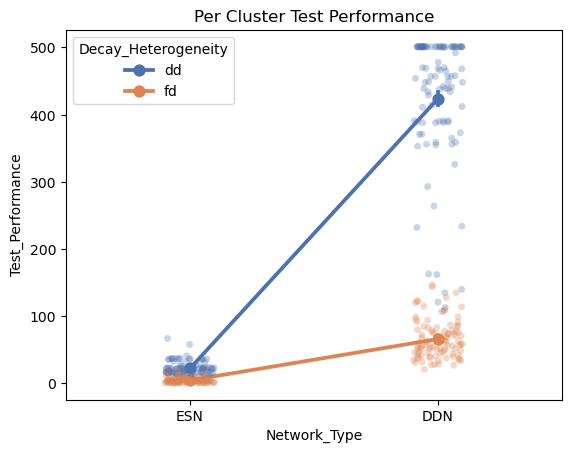

In [31]:
test_dict_pd = {
    'Network_Type': [],
    'Decay_Heterogeneity': [],
    'Test_Performance': []
}
for net_type in MG_imports:
    for het_type in MG_imports[net_type]['per_cluster']:
        test_dict = MG_imports[net_type]['per_cluster'][het_type]['test_dict']
        test_data = test_dict[17]
        print(net_type, het_type)
        print(test_data)
        test_data = list(np.max(test_data, axis=-1))        
        print(test_data)
        n_samples = len(test_data)
        test_dict_pd['Test_Performance'] += test_data
        test_dict_pd['Network_Type'] += [net_type] * n_samples
        test_dict_pd['Decay_Heterogeneity'] += [het_type] * n_samples

test_pd_cluster = pd.DataFrame.from_dict(test_dict_pd)
# sns.pointplot(test_df, x=x_label, y=y_label, hue=hue_label, errorbar='se', palette='deep', markers='o', markersize=5)

sns.pointplot(data=test_pd_cluster, x='Network_Type', hue='Decay_Heterogeneity', errorbar='se', y='Test_Performance', palette='deep', markers='o')

sns.stripplot(data=test_pd_cluster, x='Network_Type', hue='Decay_Heterogeneity', y='Test_Performance', legend=False, alpha=0.3, palette='deep')
# plt.title('Test Fixed Tau')
plt.title('Per Cluster Test Performance')
plt.savefig('G:/My Drive/Data For Publication/paper3/figs_MG/MG_per_cluster_test_performance.pdf', dpi=300, bbox_inches='tight')

## DDN vs DDN and ESN vs ESN

### Network

In [19]:
import scipy.stats as stats

# Creating data groups
print('DDN')
# Perform the two sample t-test with equal variances
print(stats.ttest_ind(a=test_pd_network[test_pd_network.Network_Type=='DDN'][test_pd_network.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(), 
                b=test_pd_network[test_pd_network.Network_Type=='DDN'][test_pd_network.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(), 
                equal_var=True))
print('ESN')
print(stats.ttest_ind(a=test_pd_network[test_pd_network.Network_Type=='ESN'][test_pd_network.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(), 
                b=test_pd_network[test_pd_network.Network_Type=='ESN'][test_pd_network.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(), 
                equal_var=True))

DDN
TtestResult(statistic=4.200059146748373, pvalue=0.0029962715486379684, df=8.0)
ESN
TtestResult(statistic=-4.261877366068679, pvalue=0.002754362687712973, df=8.0)


C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\3499192463.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(stats.ttest_ind(a=test_pd_network[test_pd_network.Network_Type=='DDN'][test_pd_network.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\3499192463.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  b=test_pd_network[test_pd_network.Network_Type=='DDN'][test_pd_network.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\3499192463.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(stats.ttest_ind(a=test_pd_network[test_pd_network.Network_Type=='ESN'][test_pd_network.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\3499192463.py:11: UserWarning: Boolean 

### Cluster heterogeneity

In [16]:
print(stats.ttest_ind(a=test_pd_cluster[test_pd_cluster.Network_Type=='DDN'][test_pd_cluster.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(), 
                b=test_pd_cluster[test_pd_cluster.Network_Type=='DDN'][test_pd_cluster.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(), 
                equal_var=True))

print(stats.ttest_ind(a=test_pd_cluster[test_pd_cluster.Network_Type=='ESN'][test_pd_cluster.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(), 
                b=test_pd_cluster[test_pd_cluster.Network_Type=='ESN'][test_pd_cluster.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(), 
                equal_var=True))

TtestResult(statistic=-13.197017243051992, pvalue=1.0355456987581862e-06, df=8.0)
TtestResult(statistic=-5.925723399062583, pvalue=0.0003514231034325768, df=8.0)


C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2134075985.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(stats.ttest_ind(a=test_pd_cluster[test_pd_cluster.Network_Type=='DDN'][test_pd_cluster.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2134075985.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  b=test_pd_cluster[test_pd_cluster.Network_Type=='DDN'][test_pd_cluster.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2134075985.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(stats.ttest_ind(a=test_pd_cluster[test_pd_cluster.Network_Type=='ESN'][test_pd_cluster.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2134075985.py:6: UserWarning: Boolean Se

## DDN vs ESN

### netwide 

In [17]:
print('heterogeneous')
print(stats.ttest_ind(a=test_pd_network[test_pd_network.Network_Type=='DDN'][test_pd_network.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(), 
                b=test_pd_network[test_pd_network.Network_Type=='ESN'][test_pd_network.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(), 
                equal_var=True))
print('homogeneous')
print(stats.ttest_ind(a=test_pd_network[test_pd_network.Network_Type=='DDN'][test_pd_network.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(), 
                b=test_pd_network[test_pd_network.Network_Type=='ESN'][test_pd_network.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(), 
                equal_var=True))

heterogeneous
TtestResult(statistic=-3.9842816545579147, pvalue=0.004037451957081562, df=8.0)
homogeneous
TtestResult(statistic=4.7782435913628545, pvalue=0.001393805033151024, df=8.0)


C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2282655466.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(stats.ttest_ind(a=test_pd_network[test_pd_network.Network_Type=='DDN'][test_pd_network.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2282655466.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  b=test_pd_network[test_pd_network.Network_Type=='ESN'][test_pd_network.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2282655466.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(stats.ttest_ind(a=test_pd_network[test_pd_network.Network_Type=='DDN'][test_pd_network.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2282655466.py:7: UserWarning: Boolean Se

### Cluster wide

In [ ]:
print('heterogeneous')
print(stats.ttest_ind(a=test_pd_cluster[test_pd_cluster.Network_Type=='DDN'][test_pd_cluster.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(), 
                b=test_pd_cluster[test_pd_cluster.Network_Type=='ESN'][test_pd_cluster.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(), 
                equal_var=True))

print('homogeneous')
print(stats.ttest_ind(a=test_pd_cluster[test_pd_cluster.Network_Type=='DDN'][test_pd_cluster.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(), 
                b=test_pd_cluster[test_pd_cluster.Network_Type=='ESN'][test_pd_cluster.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(), 
                equal_var=True))

heterogeneous
TtestResult(statistic=8.339983760705001, pvalue=3.2324186841844165e-05, df=8.0)
homogeneous
TtestResult(statistic=10.011572251518158, pvalue=8.415197592722198e-06, df=8.0)


C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2270244568.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(stats.ttest_ind(a=test_pd_cluster[test_pd_cluster.Network_Type=='DDN'][test_pd_cluster.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2270244568.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  b=test_pd_cluster[test_pd_cluster.Network_Type=='ESN'][test_pd_cluster.Decay_Heterogeneity == 'dd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2270244568.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(stats.ttest_ind(a=test_pd_cluster[test_pd_cluster.Network_Type=='DDN'][test_pd_cluster.Decay_Heterogeneity == 'fd' ]['Test_Performance'].to_numpy(),
C:\Users\Nishant Joshi\AppData\Local\Temp\ipykernel_29096\2270244568.py:7: UserWarning: Boolean Se